<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/DL_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import classification_report, confusion_matrix

In [10]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

In [8]:
print(ds)

print(ds['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [11]:
train_text = dataset['train']['text']
train_label = dataset['train']['label']

test_text = dataset['test']['text']
test_label = dataset['test']['label']

In [12]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(train_text)

X_train = tokenizer.texts_to_sequences(train_text)

X_test = tokenizer.texts_to_sequences(test_text)

In [13]:
max_length = 100

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding='post')

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding='post')

In [14]:
y_train = np.array(train_label)

y_test = np.array(test_label)

In [15]:
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    SimpleRNN(64),

    Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 111s 72ms/step - accuracy: 0.4528 - loss: 1.1394 - val_accuracy: 0.2600 - val_loss: 1.3906
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 112s 52ms/step - accuracy: 0.2507 - loss: 1.3897 - val_accuracy: 0.2346 - val_loss: 1.3961
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.2513 - loss: 1.3892 - val_accuracy: 0.2609 - val_loss: 1.3897
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.2515 - loss: 1.3886 - val_accuracy: 0.2633 - val_loss: 1.3872
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - accuracy: 0.2505 - loss: 1.3883 - val_accuracy: 0.2638 - val_loss: 1.3865


In [19]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2516 - loss: 1.3864
Test Accuracy: 0.2515789568424225


In [20]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [21]:
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1900
           1       0.25      1.00      0.40      1900
           2       0.00      0.00      0.00      1900
           3       1.00      0.01      0.01      1900

    accuracy                           0.25      7600
   macro avg       0.31      0.25      0.10      7600
weighted avg       0.31      0.25      0.10      7600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
print(confusion_matrix(y_test, predicted_classes))

[[   0 1900    0    0]
 [   0 1900    0    0]
 [   0 1900    0    0]
 [   1 1887    0   12]]


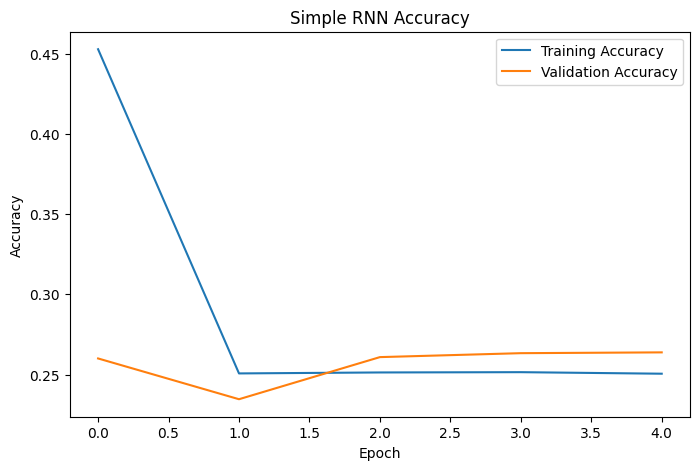

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Simple RNN Accuracy")

plt.legend()

plt.show()

In [24]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

news = ["Apple launches its latest AI-powered iPhone with advanced features."]

sequence = tokenizer.texts_to_sequences(news)

sequence = pad_sequences(sequence,
                         maxlen=max_length,
                         padding='post')

prediction = model.predict(sequence)

category = np.argmax(prediction)

print("Predicted Category:", label_names[category])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Category: Sports
